## Challenge 1: Skewness

**1.1 Definition:**

Skewness is a measure of the lack of symmetry of the
probability distribution. Mathematically, it is the third standardized moment:
\begin{equation*}
\tilde{\mu}_3 = \frac{\sum_{i=1}^N \left( \boldsymbol{X}_i - \bar{\boldsymbol{X}} \right)^3}{(N-1) \cdot \sigma^3}
\end{equation*}

**1.2 Description:**

If a distribution lacks symmetry, then it means that it doesn’t look the same to the right and left of the center point. The phenomenon is called skewness and it tells us how much (and in which direction) the data deviates from perfect symmetry by measuring the degree and direction of asymmetric in the distribution.

**1.3 Demonstration**:
We generate 500 random numbers and calculate skewness. Skewness is 0.03 and it finds that the distribution is positively skewed.

In [ ]:
# Import libraries
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew

# Generate random data
np.random.seed(0)
data = np.random.randn(500)

# Calculate skewness
skewness = skew(data)

print(f"Skewness: {skewness:.2f}")
if skewness > 0:
    print("The distribution is positively skewed.")
elif skewness < 0:
    print("The distribution is negatively skewed.")
else:
    print("The distribution is symmetric.")

Skewness: 0.03
The distribution is positively skewed.


**1.4 Diagram:**

The graph seems to be positively skewed (slightly skewed to the right) as the mean (red) is slightly increased than the median (green), implying that the data has tails (towards higher values). Such distributions often contain a few larger values drawing the mean upward and indeed this implies that there are a few larger values pulling the mean upward.

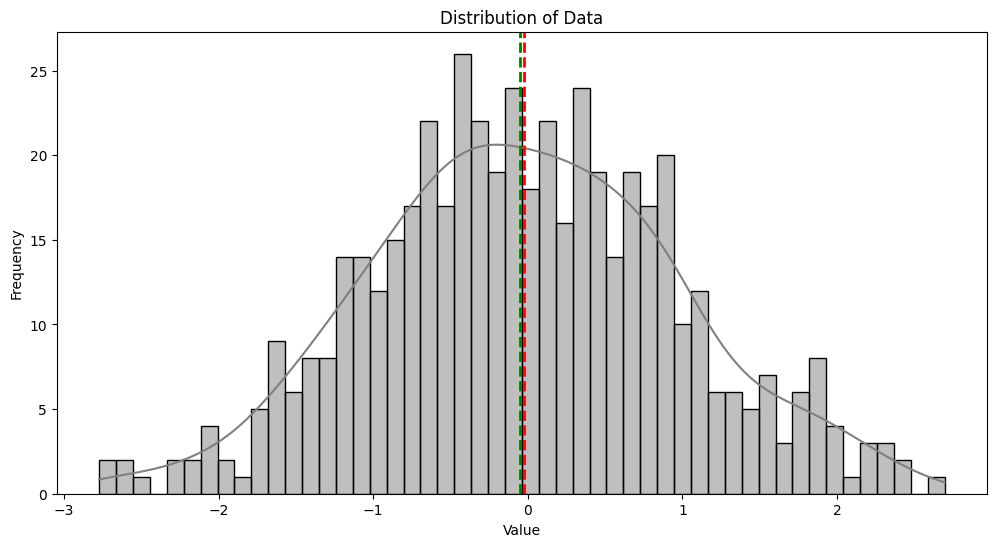

In [ ]:
# Visualize the distribution
plt.figure(figsize=(12, 6))
sns.histplot(data, bins=50, kde=True, color='gray')
plt.axvline(np.mean(data), color='red', linestyle='dashed', linewidth=2)
plt.axvline(np.median(data), color='green', linestyle='dashed', linewidth=2)
plt.title("Distribution of Data")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

**1.5 Diagnosis:**

To diagnose skewness, we can do it at a glance by constructing a histogram of the distribution and if it is asymmetrical then there is skewness. Another method is to calculate the skewness coefficient and if its absolute value is greater than 0.5 then it suggests significant skewness. Lastly, Agostino's chi-square test can also be used to verify normality. It combines skewness and kurtosis.

**1.6 Damage:**

Since means are sensitive to skewness, the 'mean’ doesn’t always provide a 'typical’ way to describe the data, and risk models may underestimate the likelihood of extreme events like market crashes. Thus, skewness can become a problem not only for asset allocation but for pricing derivatives like options and selecting poor portfolios.

**1.7  Directions:**

We can reduce skewness by transforming the data with log, square root, cube root or Box-Cox’s transformations. The skewness can also be addressed using non-normal models such as student's t distribution or minimizing the effect of skewness by focusing on the median, a more robust statistic than the mean.

## Challenge 2: Kurtosis / heteroscedasticity

**2.1 Definition**

Kurtosis quantifies how far a distribution deviates from a normal distribution in terms of having heavy or light tails. High kurtosis in financial data indicates a higher probability of dramatic price movements, which can have a big influence on option pricing models and risk management. Frequent extreme returns are indicated by a leptokurtic distribution (excess kurtosis > 0), whereas fewer extreme occurrences are suggested by a platykurtic distribution (excess kurtosis < 0). Related to this, heteroscedasticity is the existence of non-constant variance in a time series, which is frequently seen in financial markets when there is unpredictable alternating between periods of high and low volatility. Developing strong financial models requires recognizing and addressing these traits.

We define skewness mathematically as:

\begin{equation*}
\kappa = \frac{E \left[ (X - \mu)^4 \right]}{\sigma^4} - 3
\end{equation*}
**where:**

E is the expectation operator.

X is the random variable.

μ is the mean.

σ is the standard deviation.

Interpretation:

If  κ>0, the distribution is leptokurtic (fat-tailed).

If  κ< 0, the distribution is platykurtic (thin-tailed).

If  κ=0, the distribution is mesokurtic (normal-like).

**2.2 Description**

Kurtosis measures the tails of the distribution, indicating the presence of outliers and extreme values. In finance, high kurtosis suggests a higher likelihood of extreme returns, impacting risk management.

** Demonstration**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.stats import normaltest
from statsmodels.tsa.stattools import adfuller


#Generating a dataset and computing kurtosis
np.random.seed(42)
normal_data = np.random.normal(0, 1, 1000)  # Mesokurtic (≈ 0)
leptokurtic_data = np.random.laplace(0, 1, 1000)  # Leptokurtic (> 0)
platykurtic_data = np.random.uniform(-2, 2, 1000)  # Platykurtic (< 0)

# Compute kurtosis
kurt_normal = kurtosis(normal_data)
kurt_lepto = kurtosis(leptokurtic_data)
kurt_platy = kurtosis(platykurtic_data)

print(f"Kurtosis of Normal Data: {kurt_normal:.4f} (Expected ≈ 0)")
print(f"Kurtosis of Leptokurtic Data: {kurt_lepto:.4f} (Expected > 0)")
print(f"Kurtosis of Platykurtic Data: {kurt_platy:.4f} (Expected < 0)")

Kurtosis of Normal Data: 0.0662 (Expected ≈ 0)
Kurtosis of Leptokurtic Data: 2.0952 (Expected > 0)
Kurtosis of Platykurtic Data: -1.1804 (Expected < 0)


 **2.4 Diagram:**

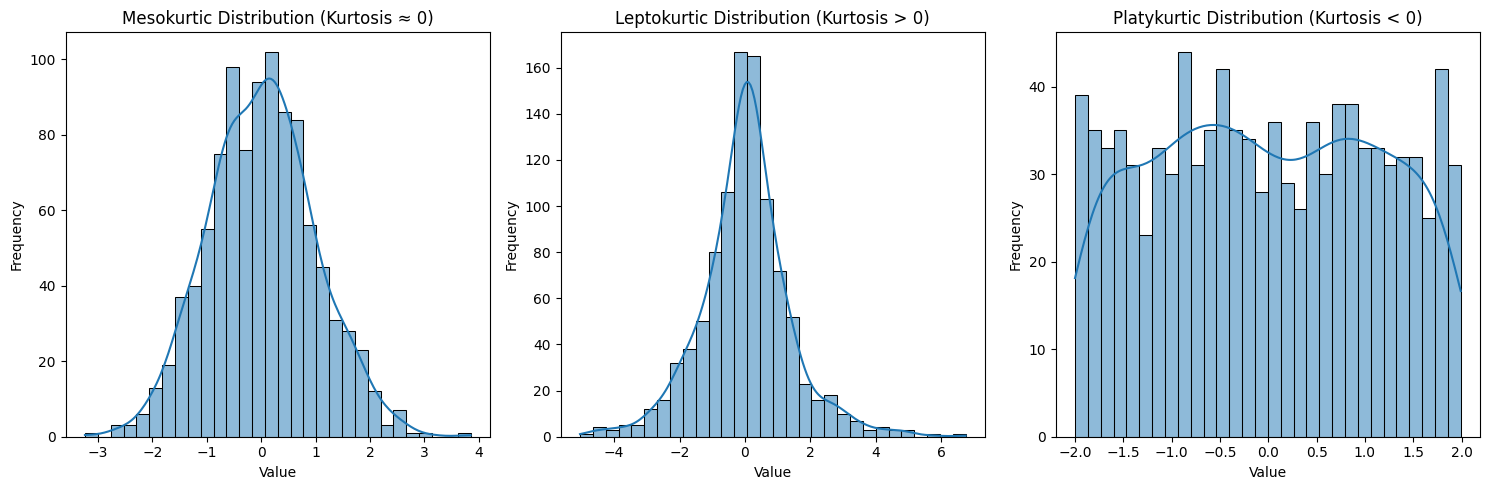

In [ ]:
# Visualizing Kurtosis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(normal_data, bins=30, kde=True, ax=axes[0])
axes[0].set_title("Mesokurtic Distribution (Kurtosis ≈ 0)")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")

sns.histplot(leptokurtic_data, bins=30, kde=True, ax=axes[1])
axes[1].set_title("Leptokurtic Distribution (Kurtosis > 0)")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Frequency")

sns.histplot(platykurtic_data, bins=30, kde=True, ax=axes[2])
axes[2].set_title("Platykurtic Distribution (Kurtosis < 0)")
axes[2].set_xlabel("Value")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**2.5 Diagnosis**

In [ ]:
# Identifying Kurtosis: Using statistical tests and empirical distributions
print("\nKurtosis Values:")
print(f"Normal Data: {kurt_normal:.4f}")
print(f"Leptokurtic Data: {kurt_lepto:.4f}")
print(f"Platykurtic Data: {kurt_platy:.4f}")


Kurtosis Values:
Normal Data: 0.0662
Leptokurtic Data: 2.0952
Platykurtic Data: -1.1804


**2.6 Damage**

Among others, extreme kurtosis can lead to underestimated or overestimated risk. Effects of Kurtosis are as follows:

**1. Extreme Tail Risks:** High kurtosis means an increased likelihood of extreme events.

**2. Volatility Clustering:** In financial markets, leptokurtic distributions indicate clustered volatility.

**3. Mispricing of Risk:** VaR models assuming normality may underestimate extreme losses.

**4. Heteroscedasticity in Time Series:** Changing variance over time complicates forecasting models.



**2.7 Directions**

We can address Kurtosis (heteroscedasticity) by doing the following:

**1 Data Transformation Techniques:**

Winsorization: Limits extreme values to reduce tail impact.
Logarithmic/Square-root Transformations: Reduce leptokurtic effects.

**2 Alternative Distributions:**

Student’s t-distribution: Handles fat tails better than normal distribution.
Generalized Error Distribution (GED): Models different tail behaviors.

**3 Risk Management Adjustments:**

Use CVaR instead of VaR to better capture tail risks.
Apply robust volatility models like GARCH to manage heteroscedasticity.

## Challenge 3: Addressing Sensitivity to Outliers

**3.1 Definition:**

Outliers are values extremely different from other values in data. Addressing the sensitivity of outliers is very important when dealing with data to deduce correct information or output. the impact of outliers can be quantified using statistical measures such as modified Z-score.


 \begin{equation*}
\ {Z} = \frac{\left(\boldsymbol{X}_i - \ {\boldsymbol{median (X)}} \right)}{MAD}
\end{equation*}

where MAD (Median Absolute Deviation) is defined as:

\begin{equation*}
\text{MAD} = \text{median} \left(\left| \boldsymbol{X}_i - \boldsymbol{\text{median}(X)} \right| \right)
\end{equation*}

**3.2 Description:**

 Outliers can lead to misleading conclusions. They can distort statistical analysis and affect the mean, variance, correlation, and regression coefficients of a data set. Deducing how sensitive data is to outliers can help to reduce time and mistakes, it also helps better Data Visualization, improve Model Performance, and prevent data corruption.


**3.3 Demonstration:**

Generate a normal dataset and introduce some extreme values as shown below.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate normal data
data = np.random.normal(50, 10, 100)

# Introduce outliers
outliers = np.array([150, 200])
data_with_outliers = np.append(data, outliers)


print( f'The Data set generated is {data_with_outliers}')



The Data set generated is [ 35.84629258  45.79354677  46.57285483  41.97722731  48.38714288
  54.04050857  68.86185901  51.74577813  52.57550391  49.25554084
  30.81228785  49.73486125  50.6023021   74.63242112  48.07639035
  53.01547342  49.6528823   38.31321962  61.42822815  57.51933033
  57.91031947  40.90612545  64.02794311  35.98148937  55.86857094
  71.90455626  40.09463675  44.3370227   50.99651365  44.96524346
  34.49336569  50.68562975  39.37696286  54.73592431  40.80575766
  65.49934405  42.16746708  46.77938484  58.13517217  37.69135684
  52.27459935  63.07142754  33.92516765  51.84633859  52.59882794
  57.81822872  37.63049289  36.79543387  55.21941566  52.96984673
  52.5049285   53.46448209  43.19975278  52.32253697  52.93072473
  42.85648582  68.65774511  54.73832921  38.08696503  56.56553609
  40.2531833   57.87084604  61.58595579  41.79317682  59.63376129
  54.12780927  58.2206016   68.96792983  47.54611884  42.46263836
  41.1048557   41.84189715  49.22898291  53.411519

**1.4 Diagram:**

The diagram plotted to show the ouliers is the Scatter Plot shown below.

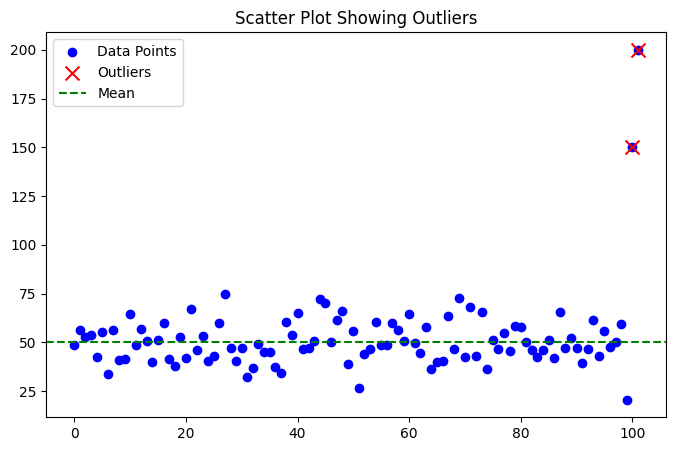

In [ ]:
# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(range(len(data_with_outliers)), data_with_outliers, color='blue', label="Data Points")
plt.scatter([len(data), len(data) + 1], outliers, color='red', label="Outliers", marker='x', s=100)
plt.axhline(np.mean(data), color='green', linestyle='dashed', label="Mean")
plt.title("Scatter Plot Showing Outliers")
plt.legend()
plt.show()

**1.5 Diagnosis:**

During diagnostics, outliers can be detected statistically using a Z-score. It can also detected visually with the help of scatter plots. The scatter plot is very effective in the outlier detection.


**1.6 Damage:**

Outliers can skew the mean and variance of a data set, leading to incorrect interferences. They can inflate type I and type II errors in hypothesis testing and cause overfitting or biased model predictions during regression.

**1.7 Directions:**

 We can reduce the effect of Outliers through log transformation which will reduce the impact of large values. Using MAD instead of mean and standard deviation can also reduce the impact of outliers. Lastly using Isolation Forests a technique in Machine learning can help to easily detect outliers.



## Challenge 4: Modeling non-stationarity and finding a unit Root Testing

**4.1 Definition:** If we have a non-stationary time series, we imply that the statistical properties of mean, variance, and autocorrelation change over time. Unit root tests help you in finding out a time series whether it is stationary or has a unit root (random walk). Mathematically, a time series \begin{equation} y_t \end{equation} follows an autoregressive process:
\begin{equation}
    y_t = \rho y_{t-1} + \epsilon_t
\end{equation}
where \begin{equation} \rho =1 \end{equation} indicates a unit root and \begin{equation} |\rho|< 1 \end{equation} indicates stationary.

**4.2 Description:** Time series non-stationarity is problematic because it violates the stationarity assumption of traditional statistical models. An econometric model applied to a unit root series is meaningless unless (e.g. by differencing) the series is transformed.

**4.3 Demonstration:**

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Generate random series
np.random.seed(42)
n = 100
eps = np.random.normal(0, 1, n)
y = np.cumsum(eps)

# Perform ADF test
adf_test = adfuller(y)
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")
print("Critical Values:", adf_test[4])

ADF Statistic: -1.3583317659818992
p-value: 0.6020814791099098
Critical Values: {'1%': np.float64(-3.498198082189098), '5%': np.float64(-2.891208211860468), '10%': np.float64(-2.5825959973472097)}


The p-value (0.6020814791099098) > 0.05, we fail to reject the null hypothesis. Then series is non-stationary.

**4.4 Diagram:**

<ipython-input-11-955881ef106c>:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


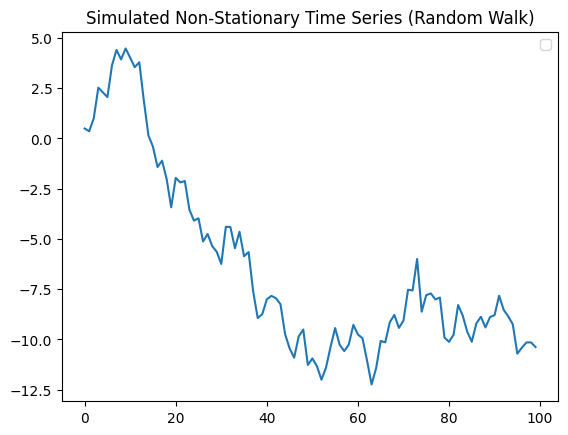

In [ ]:
plt.plot(y)
plt.title("Simulated Non-Stationary Time Series (Random Walk)")

plt.show()

**4.5 Diagnosis:**

We can test for stationarity through Augmented Dickey-Fuller (ADF) Test and KPSS Test. we can have visual inspection throth Rolling mean and variance plots




In [ ]:
# Testing for Non-Stationarity
adf_stat, p_value, _, _, _, _ = adfuller(y)
print(f"ADF Statistic: {adf_stat}, p-value: {p_value}")

ADF Statistic: -1.3583317659818992, p-value: 0.6020814791099098


**4.6 Damage:**

Effects of Non-Stationarity:

**Spurious Correlations:** Non-stationary series can falsely appear correlated.

**Poor Model Performance:** Traditional regression models assume stationarity.

**Unreliable Forecasting:** Predictions based on non-stationary data are often unstable.





**4.7 Directions:**

Differencing: Compute
\begin{equation}
    y_t = \ y + \ y_{t-1}
\end{equation}
  to help remove trend remove trends, apply log or power transformations.


We can address non-stationarity by:

**Differencing:** Convert to stationary by taking the first difference.

**Transformation: **Apply log, square-root, or Box-Cox transformations.

**Seasonal Adjustment:** Remove seasonality using moving averages or decomposition.

**Cointegration Tests:** If multiple series share a common trend, model them together.

**References**


Alexander, Carol. Market Risk Analysisb Volume I: Quantitative Methods in Finance. Chichester, John Wiley & Sons, 2008.

Alexander, Carol. Market Models: A Guide to Financial Data Analysis. Chichester, John Wiley & Sons Ltd, 2001.

Dastjerdy, B., Saeidi, A., & Heidarzadeh, S. (2023). Review of applicable outlier detection methods to treat geomechanical data. Geotechnics, 3(2), 375-396.

DeepAI. "Skewness." Machine Learning Glossary and Terms, DeepAI, URL. Accessed 22 Mar. 2025.

iSixSigma. "Skewness." iSixSigma Dictionary, www.isixsigma.com/dictionary/skewness/.

MathWorks. "Unit Root Nonstationarity." (2025) MATLAB Documentation, MathWorks, URL. Accessed 22 Mar. 2025.

Mandić-Rajčević, S., & Colosio, C. (2019). Methods for the identification of outliers and their influence on exposure assessment in agricultural pesticide applicators: A proposed approach and validation using biological monitoring. Toxics, 7(3), 37.
